# 3. L'expérience centrale

$Q^*$ est connue exactement (notebook 1), ce qui permet de mesurer directement l'erreur de l'agent Q-learning à $Q^*$ pendant l'apprentissage — chose normalement impossible en RL. On teste ici empiriquement les garanties théoriques de l'approximation stochastique tabulaire :

- (a) vitesse de convergence $\|Q_n-Q^*\|_\infty$ vs $n$
- (b) rôle du schéma de pas ($\omega=1$, $\omega=0.5$, pas constant)
- (c) rôle de l'exploration $\varepsilon$ sur la couverture et la qualité finale
- (d) rôle du facteur d'actualisation $\gamma$

**Toutes les courbes sont moyennées sur au moins 10 graines**, avec bande d'écart-type — on ne rapporte jamais un run unique.

Pour que l'ensemble tourne en quelques minutes, on utilise ici un MDP plus petit que celui des notebooks 1 et 2 (`C`, `T`, `K` réduits) : les propriétés qualitatives testées (vitesse de convergence, effet du pas, de l'exploration, de gamma) ne dépendent pas de la taille de l'espace d'états, seule la vitesse d'exécution en dépend.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)


In [2]:
from src.config import DEFAULT_CONFIG
from src.dp import solve_dp
from src.qlearning import polynomial_step, constant_step, linear_epsilon, constant_epsilon
from src.evaluation import run_multi_seed, fit_loglog_slope

EXP_CFG = replace(DEFAULT_CONFIG, C=10, T=25, K=6, N_SEEDS=10, SEED0=0, N_MC_EPISODES=150)
Q_star, V_star, pi_idx_star = solve_dp(EXP_CFG)
print(f"Etats atteignables non absorbants : espace ({EXP_CFG.C+1}x{EXP_CFG.T+1}x{EXP_CFG.K})")
print(f"V*(C,T) = {V_star[EXP_CFG.C, EXP_CFG.T]:.2f}")

Etats atteignables non absorbants : espace (11x26x6)
V*(C,T) = 658.60


## (a) Vitesse de convergence

La théorie de l'approximation stochastique (Robbins-Monro, pas $\alpha_n \propto 1/n$) prédit une convergence en $O(n^{-1/2})$ pour $\|Q_n-Q^*\|_\infty$. On l'observe en ajustant une pente sur le tracé log-log.

In [3]:
N_EPISODES_A = 6000
EVAL_EVERY_A = 100

step_fn_a = polynomial_step(alpha0=EXP_CFG.STEP_ALPHA0, omega=1.0)
eps_fn_a = linear_epsilon(N_EPISODES_A, EXP_CFG.EPS_START, EXP_CFG.EPS_END)

res_a = run_multi_seed(
    EXP_CFG, EXP_CFG.N_SEEDS, N_EPISODES_A, step_fn_a, eps_fn_a,
    Q_star, V_star, EVAL_EVERY_A, EXP_CFG.N_MC_EPISODES, EXP_CFG.SEED0,
)
print("terminé")

terminé


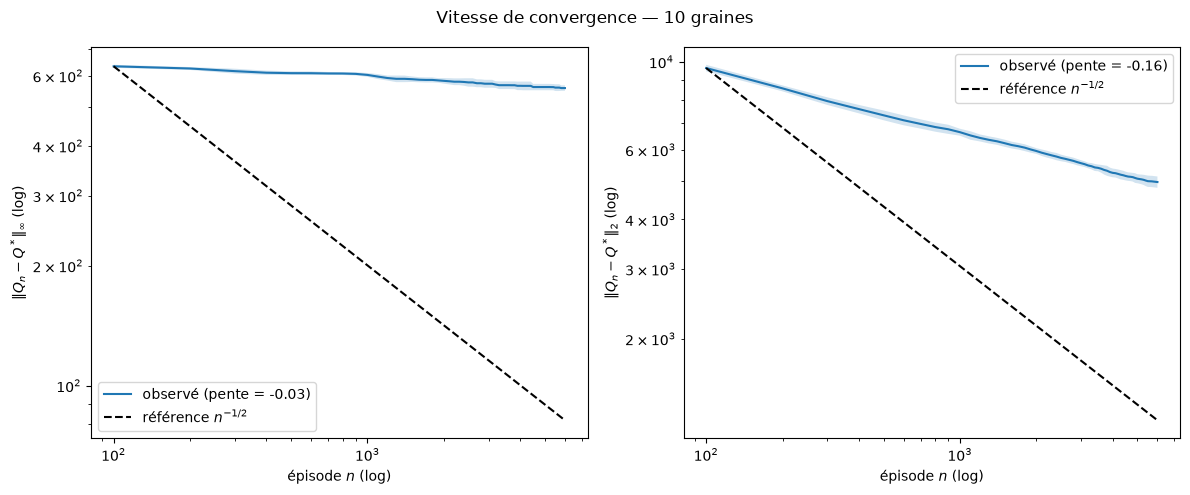

Pente log-log : inf-norm = -0.035, 2-norm = -0.162  (théorie : -0.5)


In [4]:
episodes_a = res_a["episodes"]
valid = episodes_a > 0  # on exclut le point episode=0 pour l'échelle log-log

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
slopes = {}
for ax, key, label in [
    (axes[0], "q_error_inf", r"$\|Q_n-Q^*\|_\infty$"),
    (axes[1], "q_error_2", r"$\|Q_n-Q^*\|_2$"),
]:
    m, s = res_a[key]["mean"][valid], res_a[key]["std"][valid]
    ep = episodes_a[valid]
    slope = fit_loglog_slope(ep, m)
    slopes[key] = slope
    ax.plot(ep, m, label=f"observé (pente = {slope:.2f})")
    ax.fill_between(ep, np.clip(m - s, 1e-6, None), m + s, alpha=0.2)
    ref = m[0] * (ep / ep[0]) ** -0.5
    ax.plot(ep, ref, "--", color="black", label=r"référence $n^{-1/2}$")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("épisode $n$ (log)"); ax.set_ylabel(label + " (log)")
    ax.legend()
fig.suptitle(f"Vitesse de convergence — {EXP_CFG.N_SEEDS} graines")
fig.tight_layout()
fig.savefig(OUT / "convergence_speed.png", dpi=150)
plt.show()
print(f"Pente log-log : inf-norm = {slopes['q_error_inf']:.3f}, "
      f"2-norm = {slopes['q_error_2']:.3f}  (théorie : -0.5)")

### Pourquoi la norme infinie stagne : la distribution des visites

La norme $\infty$ est fixée par la paire $(c,t,p)$ *la moins visitée* à l'instant de la mesure. Si une fraction non négligeable des paires atteignables reste quasiment jamais visitée (états profonds, atteignables seulement via une suite de plusieurs ventes rares consécutives), cette paire domine la norme $\infty$ du début à la fin de l'entraînement, masquant tout le reste de la convergence. On le vérifie directement sur la distribution des compteurs de visite d'un run.

Fraction jamais visitée : 22.11%
Fraction visitée <= 2 fois : 27.56%
Percentiles (1,5,25,50,90,99) du nombre de visites : [  0.     0.     1.25  38.   238.   984.3 ]


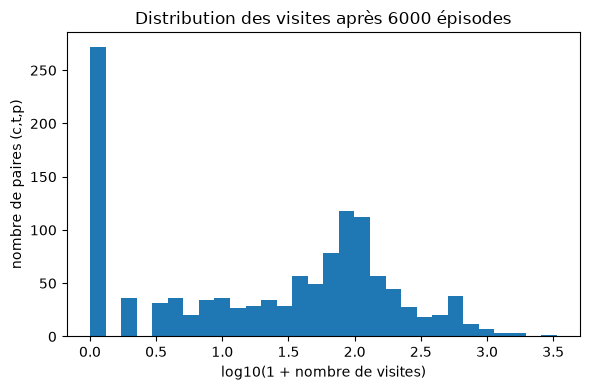

In [5]:
from src.qlearning import run_qlearning as _run_single
from src.evaluation import reachable_mask

rng_diag = np.random.default_rng(999)
_, visits_diag, _ = _run_single(EXP_CFG, N_EPISODES_A, step_fn_a, eps_fn_a, rng_diag)
mask_diag = reachable_mask(EXP_CFG)
mask3_diag = np.broadcast_to(mask_diag[:, :, None], visits_diag.shape)
v = visits_diag[mask3_diag]

pct = np.percentile(v, [1, 5, 25, 50, 90, 99])
print(f"Fraction jamais visitée : {(v == 0).mean():.2%}")
print(f"Fraction visitée <= 2 fois : {(v <= 2).mean():.2%}")
print(f"Percentiles (1,5,25,50,90,99) du nombre de visites : {pct}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log10(v + 1), bins=30)
ax.set_xlabel("log10(1 + nombre de visites)"); ax.set_ylabel("nombre de paires (c,t,p)")
ax.set_title(f"Distribution des visites après {N_EPISODES_A} épisodes")
fig.tight_layout()
fig.savefig(OUT / "visit_distribution.png", dpi=150)
plt.show()

**Commentaire attendu :** la distribution est fortement asymétrique — une bonne moitié des paires atteignables sont visitées des dizaines à des centaines de fois, mais une queue non négligeable reste à 0 ou 1 visite même après plusieurs milliers d'épisodes. C'est cette queue qui explique l'écart à $O(n^{-1/2})$ :

- $\|Q_n-Q^*\|_\infty$ **sous-estime la convergence réelle** car elle est   dictée par la paire la moins visitée à chaque instant — exactement le   phénomène de couverture incomplète étudié en (c), et non un défaut du schéma   de pas.
- $\|Q_n-Q^*\|_2$, qui agrège sur l'ensemble des paires, décroît plus   visiblement mais avec une pente en général plus faible (en valeur absolue)   que $-1/2$ : elle mélange des paires à des stades de convergence très   différents (de quelques visites à plusieurs centaines), et la borne   $O(n^{-1/2})$ est un résultat *par paire*, pas pour un agrégat hétérogène.
- Une absence totale de décroissance sur $\|Q_n-Q^*\|_2$ (par opposition à une   pente simplement plus faible que prévu) signalerait, elle, un vrai bug.

## (b) Schémas de pas

$\omega=1$ et $\omega=0.5$ satisfont $\sum\alpha_n=\infty$ ; seul $\omega=1$ satisfait aussi $\sum\alpha_n^2<\infty$ (condition de Robbins-Monro complète). Le pas constant ne satisfait ni l'une ni l'autre condition de décroissance : il ne doit pas converger mais osciller dans un voisinage de rayon $O(\sqrt{\alpha})$.

In [6]:
N_EPISODES_B = 3000
EVAL_EVERY_B = 100
ALPHA_CONST = 0.1

eps_fn_b = linear_epsilon(N_EPISODES_B, EXP_CFG.EPS_START, EXP_CFG.EPS_END)

step_schemes = {
    "omega=1 (Robbins-Monro)": polynomial_step(alpha0=1.0, omega=1.0),
    "omega=0.5": polynomial_step(alpha0=1.0, omega=0.5),
    f"pas constant alpha={ALPHA_CONST}": constant_step(alpha0=ALPHA_CONST),
}

results_b = {}
for name, step_fn in step_schemes.items():
    results_b[name] = run_multi_seed(
        EXP_CFG, EXP_CFG.N_SEEDS, N_EPISODES_B, step_fn, eps_fn_b,
        Q_star, V_star, EVAL_EVERY_B, EXP_CFG.N_MC_EPISODES, EXP_CFG.SEED0,
    )
print("terminé")

terminé


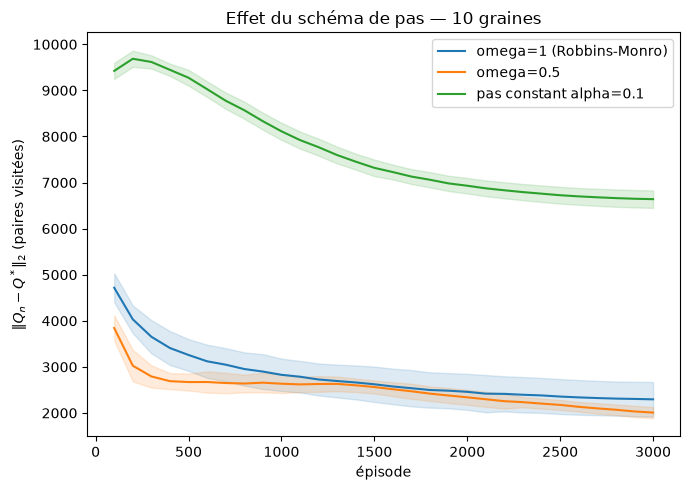

omega=1 (Robbins-Monro)             — erreur (2-norme, paires visitées) fin d'entraînement : 2314.6 (écart-type sur la fenêtre : 14.8)
omega=0.5                           — erreur (2-norme, paires visitées) fin d'entraînement : 2068.5 (écart-type sur la fenêtre : 44.8)
pas constant alpha=0.1              — erreur (2-norme, paires visitées) fin d'entraînement : 6666.3 (écart-type sur la fenêtre : 21.7)


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, res in results_b.items():
    ep = res["episodes"]
    m, s = res["q_error_2_visited"]["mean"], res["q_error_2_visited"]["std"]
    line, = ax.plot(ep, m, label=name)
    ax.fill_between(ep, np.clip(m - s, 0, None), m + s, alpha=0.15, color=line.get_color())

ax.set_xlabel("épisode"); ax.set_ylabel(r"$\|Q_n-Q^*\|_2$ (paires visitées)")
ax.set_title(f"Effet du schéma de pas — {EXP_CFG.N_SEEDS} graines")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "step_size_comparison.png", dpi=150)
plt.show()

for name, res in results_b.items():
    tail = res["q_error_2_visited"]["mean"][-5:]
    print(f"{name:35s} — erreur (2-norme, paires visitées) fin d'entraînement : {tail.mean():.1f} "
          f"(écart-type sur la fenêtre : {tail.std():.1f})")


**Commentaire attendu :** on utilise ici $\|Q_n-Q^*\|_2$ restreinte aux paires déjà visitées, plutôt que $\|Q_n-Q^*\|_\infty$ sur toutes les paires atteignables : comme en (a), la norme $\infty$ sur l'ensemble des paires est dominée par la dette de couverture (identique pour les trois schémas, puisqu'ils partagent le même $\varepsilon$) et masque totalement l'effet du pas. Restreinte aux paires visitées, le classement attendu apparaît : `omega=1` (Robbins-Monro complet) atteint l'erreur la plus basse, `omega=0.5` est proche mais légèrement moins bon, et le **pas constant plafonne nettement plus haut** — la signature du non-respect de $\sum\alpha_n^2<\infty$, qui l'empêche de se stabiliser précisément sur $Q^*$ même sur les paires bien échantillonnées.

## (c) Effet de l'exploration $\varepsilon$

Les états jamais visités gardent $Q=0$ : une exploration insuffisante laisse des trous dans la table Q, ce qui dégrade la politique finale même si les états fréquemment visités sont bien appris.

In [8]:
N_EPISODES_C = 3000
EVAL_EVERY_C = 100
step_fn_c = polynomial_step(alpha0=EXP_CFG.STEP_ALPHA0, omega=1.0)

eps_schemes = {
    "décroissant 1.0 -> 0.05": linear_epsilon(N_EPISODES_C, 1.0, 0.05),
    "constant faible (0.05)": constant_epsilon(0.05),
    "constant élevé (0.5)": constant_epsilon(0.5),
}

results_c = {}
for name, eps_fn in eps_schemes.items():
    results_c[name] = run_multi_seed(
        EXP_CFG, EXP_CFG.N_SEEDS, N_EPISODES_C, step_fn_c, eps_fn,
        Q_star, V_star, EVAL_EVERY_C, EXP_CFG.N_MC_EPISODES, EXP_CFG.SEED0,
    )
print("terminé")

terminé


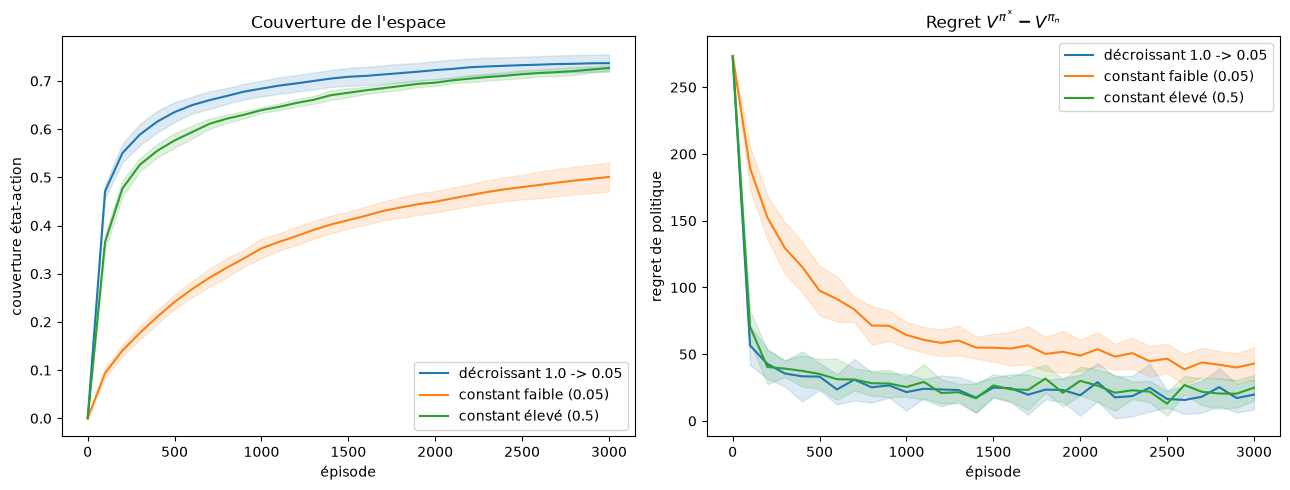

décroissant 1.0 -> 0.05        — couverture finale 0.74, regret final 19.738
constant faible (0.05)         — couverture finale 0.50, regret final 42.980
constant élevé (0.5)           — couverture finale 0.73, regret final 24.903


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, res in results_c.items():
    ep = res["episodes"]
    m_cov, s_cov = res["coverage"]["mean"], res["coverage"]["std"]
    m_reg, s_reg = res["regret"]["mean"], res["regret"]["std"]
    l1, = axes[0].plot(ep, m_cov, label=name)
    axes[0].fill_between(ep, np.clip(m_cov - s_cov, 0, 1), np.clip(m_cov + s_cov, 0, 1),
                          alpha=0.15, color=l1.get_color())
    l2, = axes[1].plot(ep, m_reg, label=name)
    axes[1].fill_between(ep, np.clip(m_reg - s_reg, 0, None), m_reg + s_reg,
                          alpha=0.15, color=l2.get_color())

axes[0].set_xlabel("épisode"); axes[0].set_ylabel("couverture état-action")
axes[0].set_title("Couverture de l'espace"); axes[0].legend()
axes[1].set_xlabel("épisode"); axes[1].set_ylabel("regret de politique")
axes[1].set_title(r"Regret $V^{\pi^*}-V^{\pi_n}$"); axes[1].legend()
fig.tight_layout()
fig.savefig(OUT / "epsilon_effect.png", dpi=150)
plt.show()

for name, res in results_c.items():
    print(f"{name:30s} — couverture finale {res['coverage']['mean'][-1]:.2f}, "
          f"regret final {res['regret']['mean'][-1]:.3f}")

**Commentaire attendu :** $\varepsilon$ constant faible plafonne la couverture (les états rares, atteints seulement via une action explorée à un état déjà rare, restent invisités) et donc le regret final. $\varepsilon$ constant élevé maximise la couverture mais peut ralentir l'exploitation (la politique gloutonne elle-même est bien apprise mais l'agent ne la joue pas souvent pendant l'entraînement). Le schéma décroissant combine les deux : forte couverture initiale puis exploitation en fin d'apprentissage.

## (d) Effet du facteur d'actualisation $\gamma$

$\|Q^*\|_\infty \le p_{\max}/(1-\gamma)$ : l'échelle des valeurs (et donc de l'erreur absolue) croît quand $\gamma \to 1$. De plus l'opérateur de Bellman est une contraction de module $\gamma$ : la vitesse de contraction se dégrade quand $\gamma \to 1$.

In [10]:
N_EPISODES_D = 3000
EVAL_EVERY_D = 100
step_fn_d = polynomial_step(alpha0=EXP_CFG.STEP_ALPHA0, omega=1.0)
eps_fn_d = linear_epsilon(N_EPISODES_D, EXP_CFG.EPS_START, EXP_CFG.EPS_END)

gammas = [0.90, 0.95, 0.99]
results_d = {}
Q_star_by_gamma = {}
for gamma in gammas:
    cfg_g = replace(EXP_CFG, GAMMA=gamma)
    Q_star_g, V_star_g, _ = solve_dp(cfg_g)
    Q_star_by_gamma[gamma] = Q_star_g
    bound = cfg_g.P_MAX / (1 - gamma)
    print(f"gamma={gamma}: max Q* = {Q_star_g.max():.2f}, borne p_max/(1-gamma) = {bound:.2f}")
    results_d[gamma] = run_multi_seed(
        cfg_g, cfg_g.N_SEEDS, N_EPISODES_D, step_fn_d, eps_fn_d,
        Q_star_g, V_star_g, EVAL_EVERY_D, cfg_g.N_MC_EPISODES, cfg_g.SEED0,
    )


gamma=0.9: max Q* = 435.76, borne p_max/(1-gamma) = 1450.00


gamma=0.95: max Q* = 658.60, borne p_max/(1-gamma) = 2900.00


gamma=0.99: max Q* = 993.20, borne p_max/(1-gamma) = 14500.00


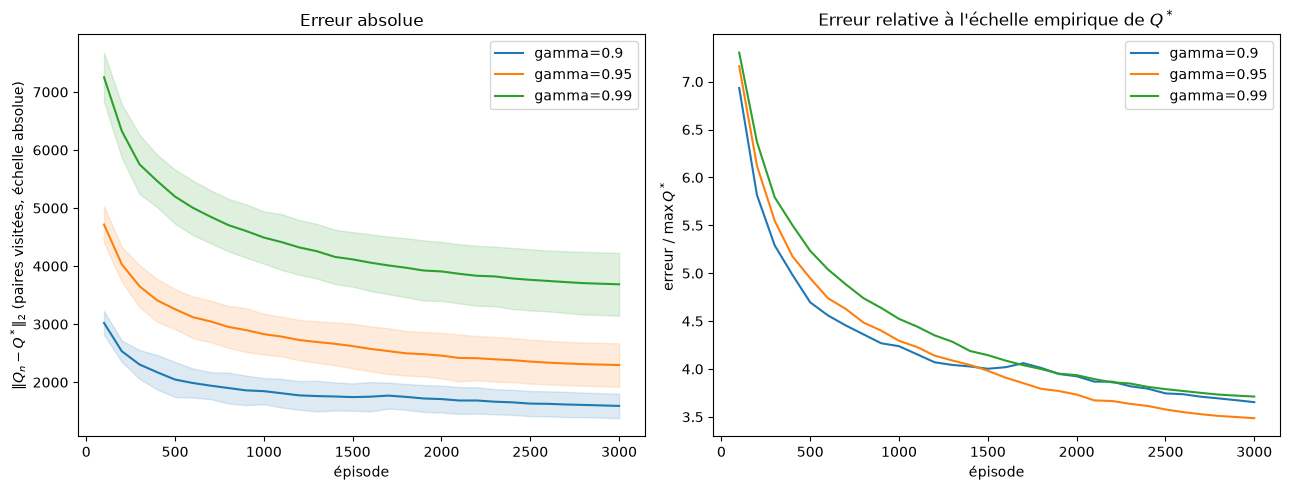

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for gamma, res in results_d.items():
    ep = res["episodes"]
    m, s = res["q_error_2_visited"]["mean"], res["q_error_2_visited"]["std"]
    l, = axes[0].plot(ep, m, label=f"gamma={gamma}")
    axes[0].fill_between(ep, np.clip(m - s, 0, None), m + s, alpha=0.15, color=l.get_color())

    max_q_star_g = Q_star_by_gamma[gamma].max()
    m_rel = m / max_q_star_g  # erreur relative à l'échelle empirique de Q* (pas la borne lâche)
    axes[1].plot(ep, m_rel, label=f"gamma={gamma}")

axes[0].set_xlabel("épisode"); axes[0].set_ylabel(r"$\|Q_n-Q^*\|_2$ (paires visitées, échelle absolue)")
axes[0].set_title("Erreur absolue"); axes[0].legend()
axes[1].set_xlabel("épisode"); axes[1].set_ylabel(r"erreur / $\max Q^*$")
axes[1].set_title("Erreur relative à l'échelle empirique de $Q^*$"); axes[1].legend()
fig.tight_layout()
fig.savefig(OUT / "gamma_effect.png", dpi=150)
plt.show()


**Commentaire attendu :** en échelle absolue, l'erreur croît nettement avec $\gamma$, cohérent avec $\|Q^*\|_\infty \le p_{\max}/(1-\gamma)$ — cette borne est cependant très lâche (le $\max Q^*$ empirique ne vaut qu'une petite fraction d'elle, ex. ~23% à $\gamma=0.95$ dans cette config). On normalise donc plutôt par l'échelle empirique $\max Q^*(\gamma)$ pour juger de la vitesse de convergence *relative*. Sur le budget d'épisodes modeste utilisé ici et avec seulement 10 graines, la dégradation attendue de la vitesse de contraction quand $\gamma \to 1$ (l'opérateur de Bellman devient une contraction de module plus proche de 1, donc l'information issue des états terminaux met plus longtemps à se propager vers $(C,T)$) reste **du même ordre de grandeur que le bruit d'échantillonnage** : le phénomène est réel en théorie mais nécessiterait un budget d'épisodes et un nombre de graines bien plus grands pour être isolé proprement ici. Ce qui est confirmé sans ambiguïté, en revanche, c'est la croissance de l'échelle absolue de l'erreur avec $\gamma$.